In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
DATA_PATH="../dataset/archive/diabetic_data.csv"
df=pd.read_csv(DATA_PATH,na_values="?")
print("size of the dataset",df.shape)
print("=" * 60)
print("Header\n",df.head())
print("=" * 60)
print("data type\n",df.dtypes)
print('='*60)
print("description\n",df.describe())

size of the dataset (101766, 50)
Header
    encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)    NaN   
1        149190     55629189        Caucasian  Female  [10-20)    NaN   
2         64410     86047875  AfricanAmerican  Female  [20-30)    NaN   
3        500364     82442376        Caucasian    Male  [30-40)    NaN   
4         16680     42519267        Caucasian    Male  [40-50)    NaN   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...

In [3]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "percent": missing_pct})
missing_df = missing_df[missing_df["count"] > 0].sort_values("percent", ascending=False)
print('='*60)
print(missing_df)

print("\n\nDuplicate rows :", df.duplicated().sum())
print("Unique patients:", df["patient_nbr"].nunique())
print("Unique encounters:", df["encounter_id"].nunique())


MISSING VALUES
                   count  percent
weight             98569    96.86
max_glu_serum      96420    94.75
A1Cresult          84748    83.28
medical_specialty  49949    49.08
payer_code         40256    39.56
race                2273     2.23
diag_3              1423     1.40
diag_2               358     0.35
diag_1                21     0.02


Duplicate rows : 0
Unique patients: 71518
Unique encounters: 101766


In [4]:
print("\n" + "=" * 60)
print("DATA CLEANING")
print("=" * 60)

# 3-a  Drop high-missing columns (>40 %)
high_missing_cols = missing_pct[missing_pct > 40].index.tolist()
print(f"\nDropping high-missing columns (>40 %): {high_missing_cols}")
df.drop(columns=high_missing_cols, inplace=True, errors="ignore")

# 3-b  Remove deceased patients — they cannot be readmitted
DECEASED_CODES = [11, 19, 20, 21]
before_deceased = len(df)
deceased_mask = df["discharge_disposition_id"].isin(DECEASED_CODES)
print(f"\nDeceased patients (discharge_disposition_id {DECEASED_CODES}): {deceased_mask.sum()}")
df = df[~deceased_mask].copy()
print(f"Dropped {before_deceased - len(df)} deceased rows  →  {len(df)} rows left")

# 3-c  Impute remaining gaps moved to training.ipynb to prevent data leakage
# 3-d  Keep only the first encounter per patient to avoid data leakage
before_dedup = len(df)
df = df.sort_values("encounter_id").drop_duplicates(subset="patient_nbr", keep="first")
print(f"\nDeduplicated to first encounter per patient: dropped {before_dedup - len(df)} rows  →  {len(df)} rows left")

# 3-e  Drop identifier / single-value columns (after dedup)
useless_cols = ["encounter_id", "patient_nbr",              # identifiers
                "examide", "citoglipton"]                    # single-value cols
useless_cols = [c for c in useless_cols if c in df.columns]
print(f"Dropping identifier columns: {useless_cols}")
df.drop(columns=useless_cols, inplace=True, errors="ignore")

remaining_deceased = df["discharge_disposition_id"].isin(DECEASED_CODES).sum()
print(f"Deceased patients remaining: {remaining_deceased}")

# 3-f  Simplify target variable
#      Original: NO, >30, <30  →  Binary: 0 (not readmitted / >30 days), 1 (<30 days)
print("\nTarget distribution (original):")
print(df["readmitted"].value_counts())

df["readmitted_binary"] = df["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

print("\nTarget distribution (binary — readmitted <30 days):")
print(df["readmitted_binary"].value_counts())

id_like = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]
for col in id_like:
    df[col] = df[col].astype("category")

print(f"\nCleaned shape: {df.shape}")
print("Remaining missing values:", df.isnull().sum().sum())


DATA CLEANING

Dropping high-missing columns (>40 %): ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']

Deceased patients (discharge_disposition_id [11, 19, 20, 21]): 1652
Dropped 1652 deceased rows  →  100114 rows left



Deduplicated to first encounter per patient: dropped 29675 rows  →  70439 rows left
Dropping identifier columns: ['encounter_id', 'patient_nbr', 'examide', 'citoglipton']
Deceased patients remaining: 0

Target distribution (original):
readmitted
NO     41901
>30    22242
<30     6296
Name: count, dtype: int64

Target distribution (binary — readmitted <30 days):
readmitted_binary
0    64143
1     6296
Name: count, dtype: int64

Cleaned shape: (70439, 43)
Remaining missing values: 34004



EXPLORATORY DATA ANALYSIS


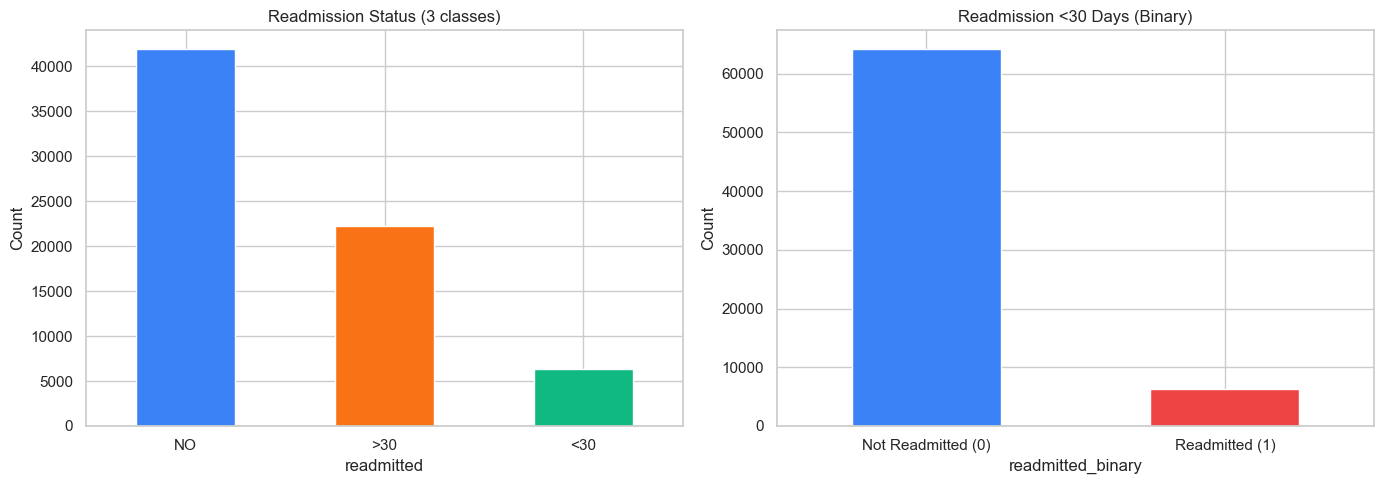

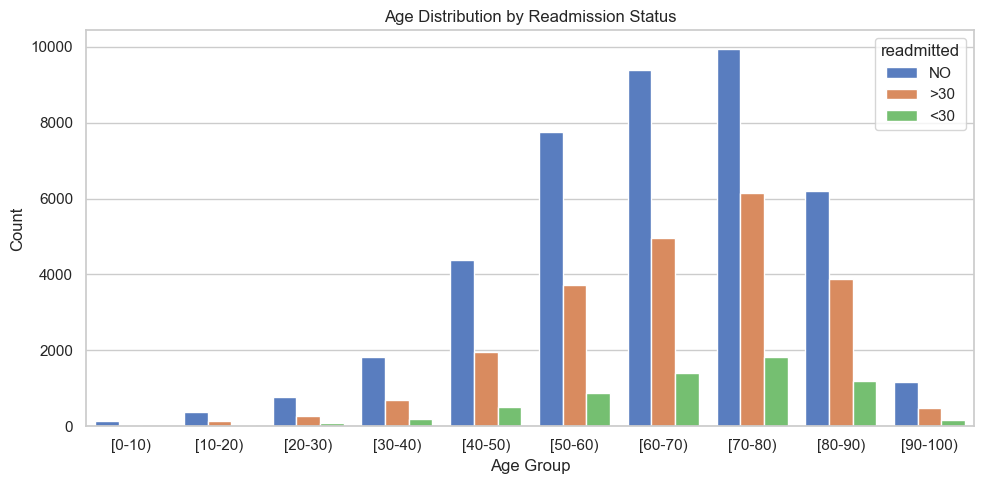

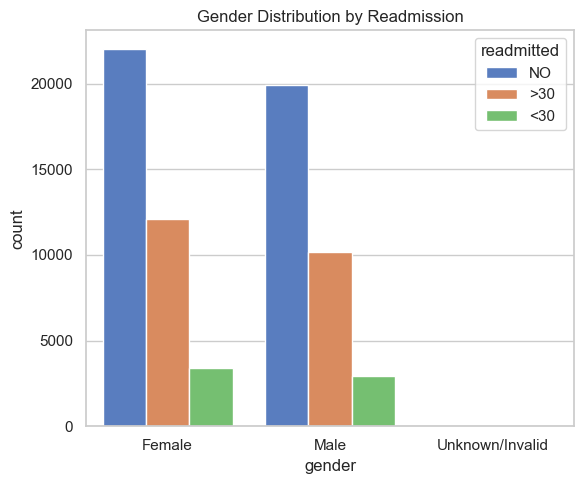

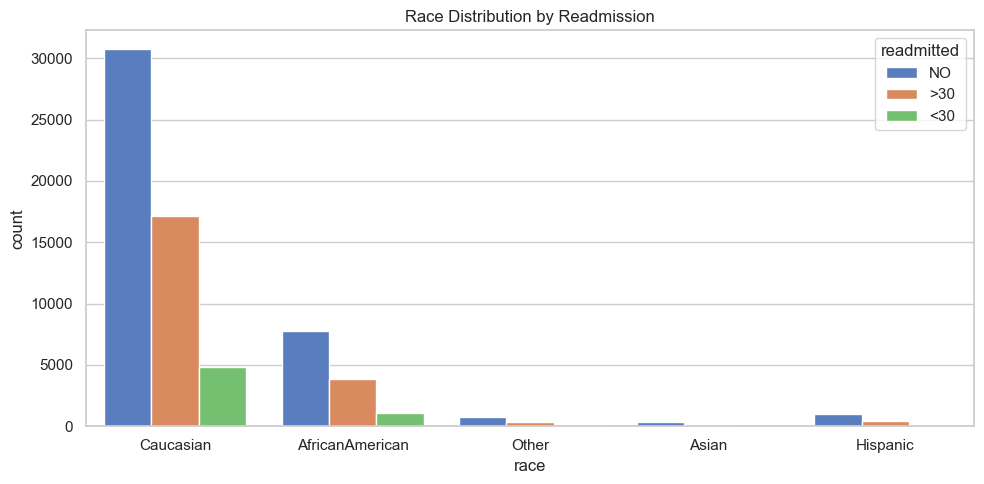

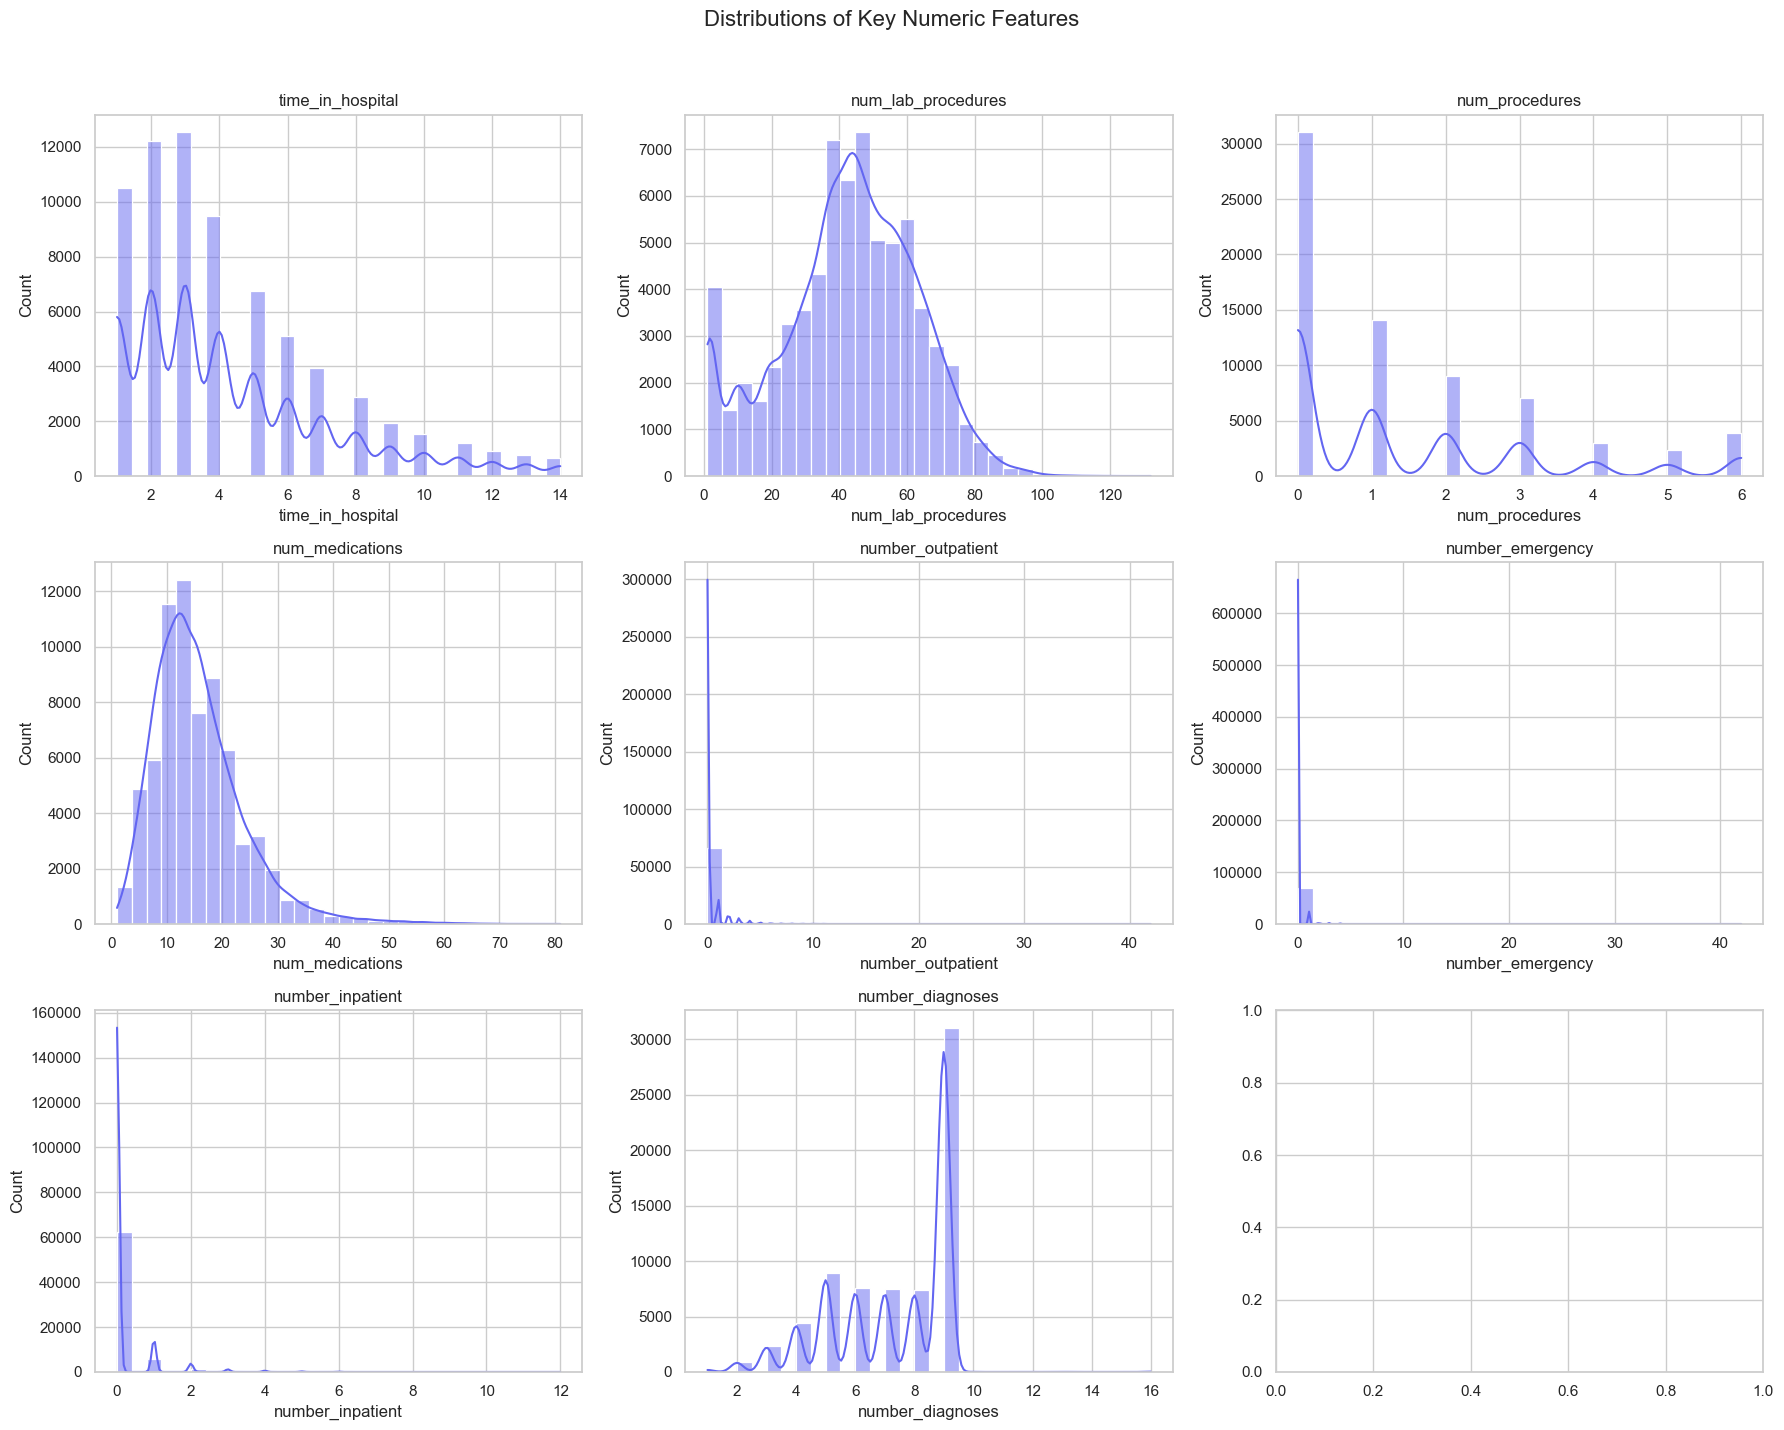

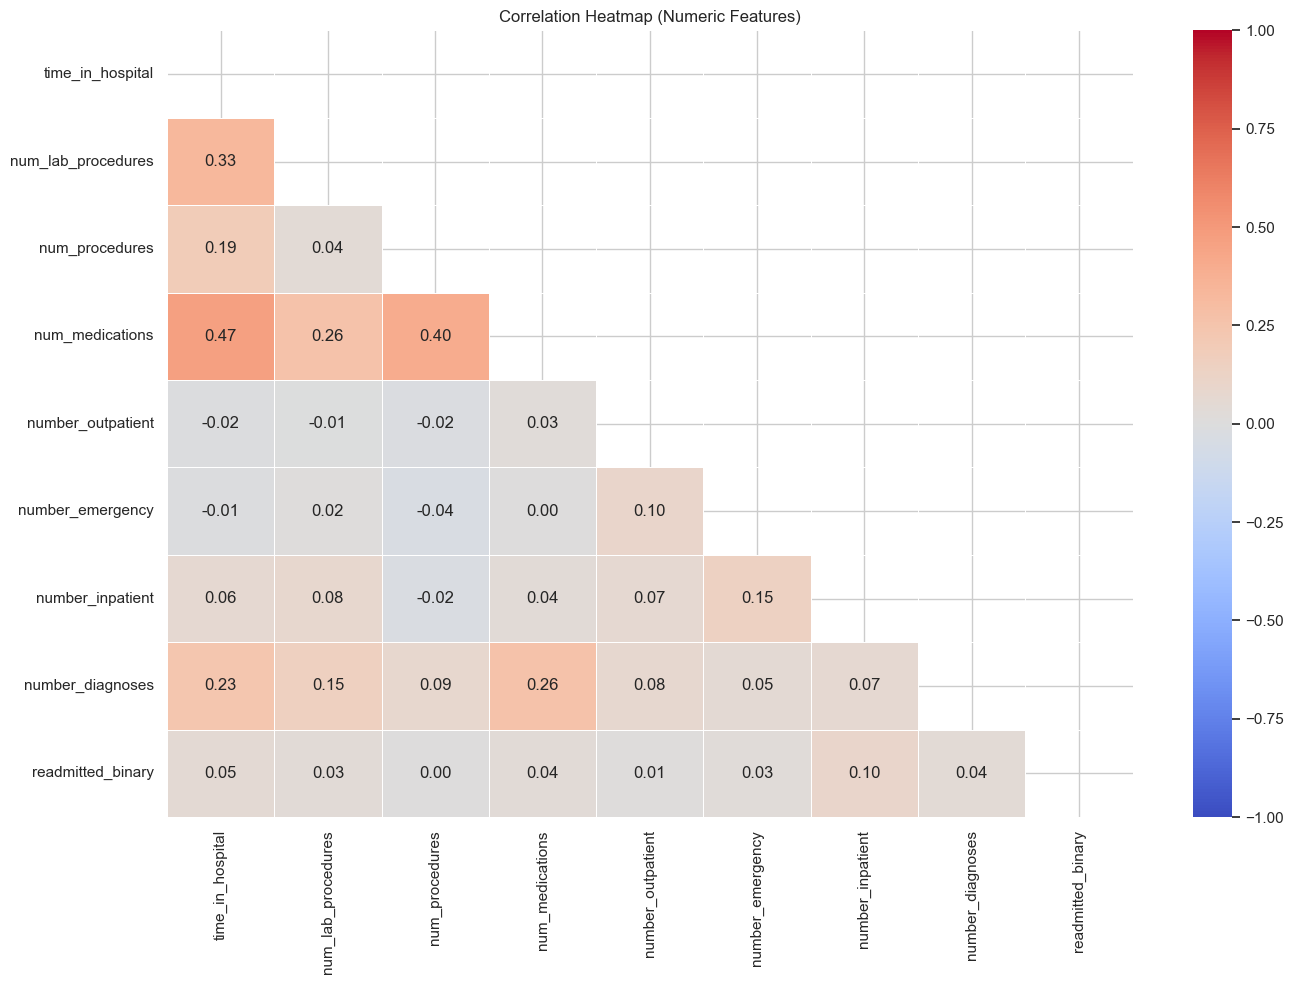

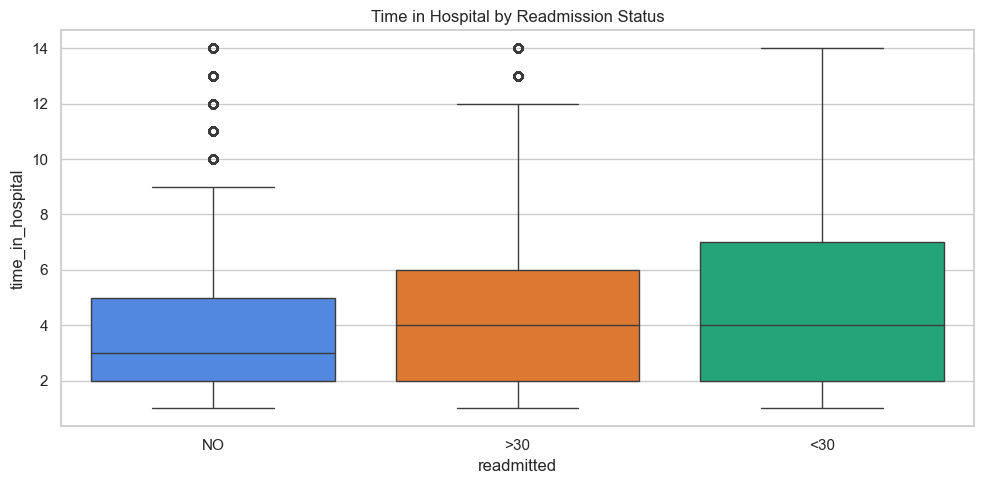

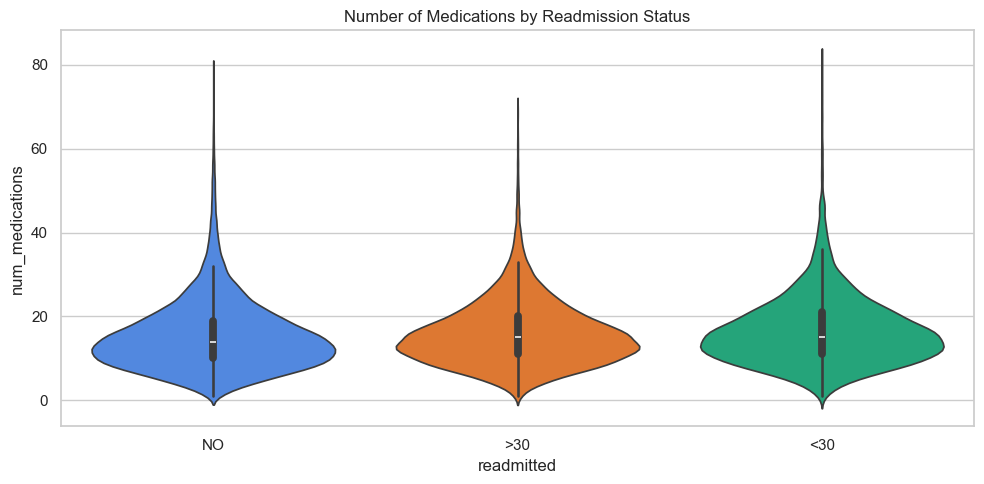

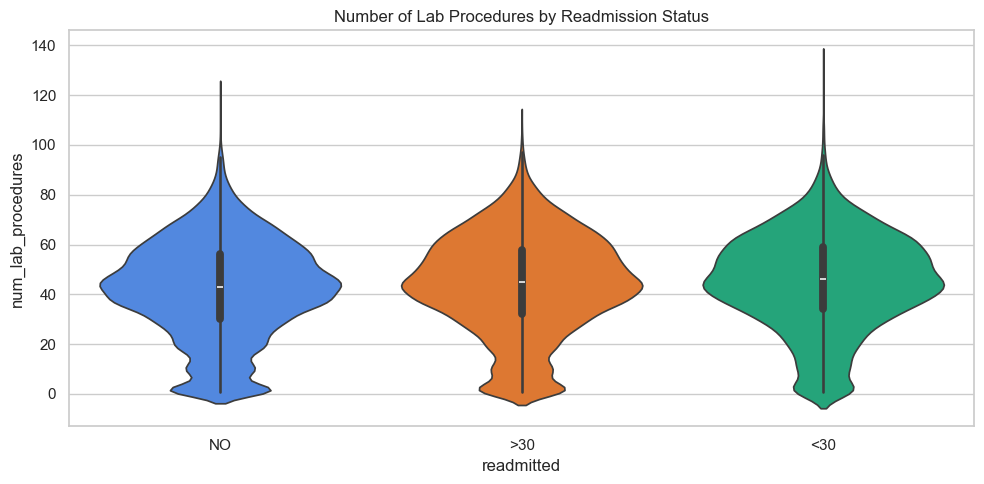

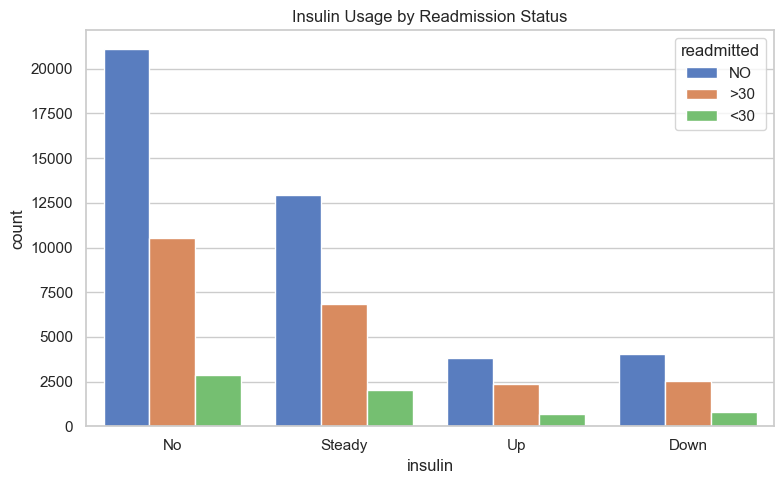

Skipping A1Cresult plot (column was dropped during cleaning)
Skipping medical_specialty plot (column was dropped during cleaning)


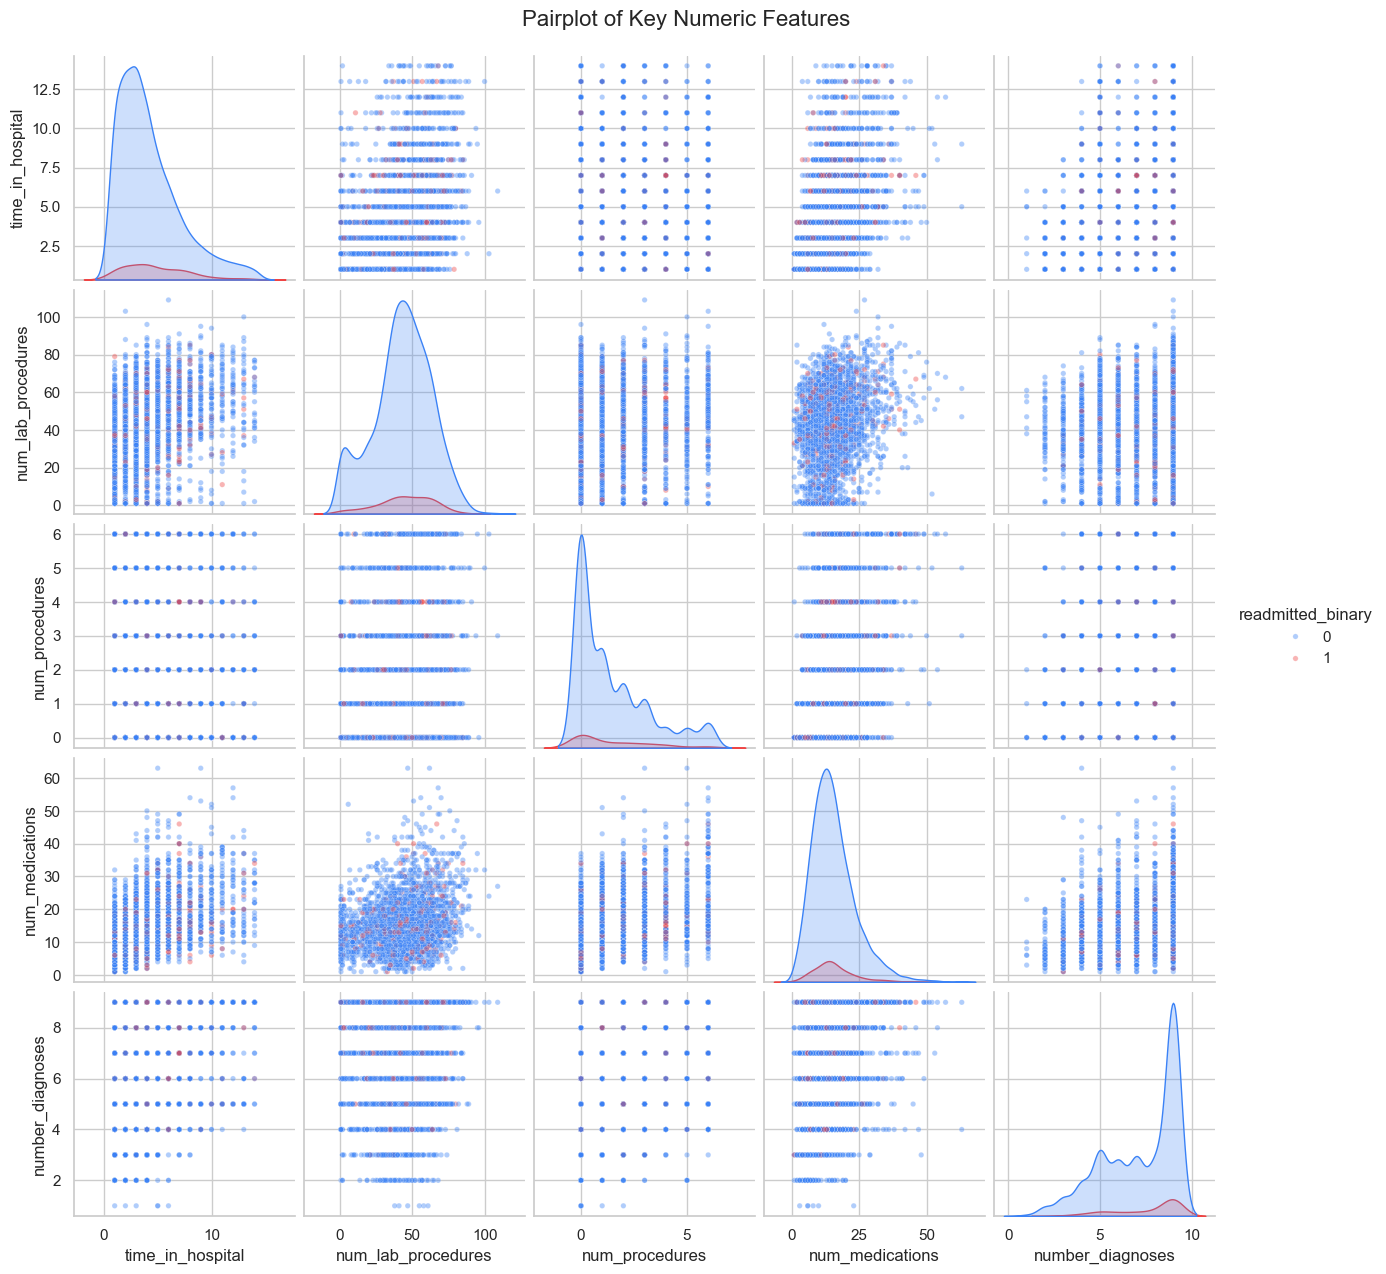

In [5]:
import os
os.makedirs("plots", exist_ok=True)

print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# 4-a  Target distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["readmitted"].value_counts().plot.bar(ax=axes[0], color=["#3b82f6", "#f97316", "#10b981"])
axes[0].set_title("Readmission Status (3 classes)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

df["readmitted_binary"].value_counts().plot.bar(ax=axes[1], color=["#3b82f6", "#ef4444"])
axes[1].set_title("Readmission <30 Days (Binary)")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["Not Readmitted (0)", "Readmitted (1)"], rotation=0)

plt.tight_layout()
plt.savefig("plots/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

#4-b  Age distribution
fig, ax = plt.subplots(figsize=(10, 5))
age_order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
             "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]
sns.countplot(data=df, x="age", order=age_order, hue="readmitted", ax=ax)
ax.set_title("Age Distribution by Readmission Status")
ax.set_xlabel("Age Group")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("plots/02_age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# 4-c  Gender distribution
fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(data=df, x="gender", hue="readmitted", ax=ax)
ax.set_title("Gender Distribution by Readmission")
plt.tight_layout()
plt.savefig("plots/03_gender_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# 4-d  Race distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x="race", hue="readmitted", ax=ax)
ax.set_title("Race Distribution by Readmission")
plt.tight_layout()
plt.savefig("plots/04_race_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# 4-e  Numeric feature distributions 
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove the binary target from histograms
numeric_cols = [c for c in numeric_cols if c != "readmitted_binary"]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:9]):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#6366f1", bins=30)
    axes[i].set_title(col)
plt.suptitle("Distributions of Key Numeric Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("plots/05_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

#  4-f  Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig("plots/06_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# 4-g  Time in hospital vs readmission 
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="readmitted", y="time_in_hospital",
            palette=["#3b82f6", "#f97316", "#10b981"], ax=ax)
ax.set_title("Time in Hospital by Readmission Status")
plt.tight_layout()
plt.savefig("plots/07_time_vs_readmission.png", dpi=150, bbox_inches="tight")
plt.show()

#  4-h  Number of medications vs readmission 
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df, x="readmitted", y="num_medications",
               palette=["#3b82f6", "#f97316", "#10b981"], ax=ax)
ax.set_title("Number of Medications by Readmission Status")
plt.tight_layout()
plt.savefig("plots/08_medications_vs_readmission.png", dpi=150, bbox_inches="tight")
plt.show()

#  4-i  Number of lab procedures vs readmission 
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df, x="readmitted", y="num_lab_procedures",
               palette=["#3b82f6", "#f97316", "#10b981"], ax=ax)
ax.set_title("Number of Lab Procedures by Readmission Status")
plt.tight_layout()
plt.savefig("plots/09_lab_procs_vs_readmission.png", dpi=150, bbox_inches="tight")
plt.show()

#  4-j  Insulin usage 
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="insulin", hue="readmitted", ax=ax,
              order=["No", "Steady", "Up", "Down"])
ax.set_title("Insulin Usage by Readmission Status")
plt.tight_layout()
plt.savefig("plots/10_insulin_vs_readmission.png", dpi=150, bbox_inches="tight")
plt.show()

#  4-k  A1C result 
if "A1Cresult" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.countplot(data=df, x="A1Cresult", hue="readmitted", ax=ax)
    ax.set_title("A1C Result by Readmission Status")
    plt.tight_layout()
    plt.savefig("plots/11_a1c_vs_readmission.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping A1Cresult plot (column was dropped during cleaning)")

#  4-l  Top 15 medical specialties 
if "medical_specialty" in df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    top_spec = df["medical_specialty"].value_counts().head(15)
    top_spec.plot.barh(ax=ax, color="#6366f1")
    ax.set_title("Top 15 Medical Specialties")
    ax.set_xlabel("Count")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig("plots/12_top_specialties.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping medical_specialty plot (column was dropped during cleaning)")

#  4-m  Pairplot of key numerics 
key_numerics = ["time_in_hospital", "num_lab_procedures",
                "num_procedures", "num_medications",
                "number_diagnoses", "readmitted_binary"]
pairplot_df = df[key_numerics].sample(3000, random_state=42)  # sample for speed
g = sns.pairplot(pairplot_df, hue="readmitted_binary",
                 palette={0: "#3b82f6", 1: "#ef4444"},
                 diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15})
g.figure.suptitle("Pairplot of Key Numeric Features", y=1.02, fontsize=16)
plt.savefig("plots/13_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()


In [6]:
print("\n" + "=" * 60)
print("CLEANED DATASET SUMMARY")
print("=" * 60)
print(f"  Rows              : {df.shape[0]}")
print(f"  Columns           : {df.shape[1]}")
print(f"  Numeric features  : {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"  Categorical feats : {len(df.select_dtypes(include=['object', 'category']).columns)}")
print(f"  Missing values    : {df.isnull().sum().sum()}")
print(f"  Target balance    :")
print(f"    Not readmitted <30d : {(df['readmitted_binary']==0).sum()}  "
      f"({(df['readmitted_binary']==0).mean()*100:.1f} %)")
print(f"    Readmitted <30d     : {(df['readmitted_binary']==1).sum()}  "
      f"({(df['readmitted_binary']==1).mean()*100:.1f} %)")
print("=" * 60)

# Save cleaned dataset
CLEAN_PATH = "../dataset/diabetic_cleaned.csv"
df.to_csv(CLEAN_PATH, index=False)
print(f"\nCleaned dataset saved to: {CLEAN_PATH}")


CLEANED DATASET SUMMARY
  Rows              : 70439
  Columns           : 43
  Numeric features  : 9
  Categorical feats : 34
  Missing values    : 34004
  Target balance    :
    Not readmitted <30d : 64143  (91.1 %)
    Readmitted <30d     : 6296  (8.9 %)



Cleaned dataset saved to: ../dataset/diabetic_cleaned.csv
